In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

import jax
jax.config.update('jax_default_device', 'gpu')
jax.config.update('jax_default_matmul_precision', 'highest')

In [2]:
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.linalg import orthogonal_procrustes

from sppcax.distributions import (
    MultivariateNormalInverseGamma as MVNIG,
    MeanField,
    MultivariateNormal,
)
from sppcax.distributions.gamma import InverseGamma

from sppcax.models import BayesianDynamicFactorAnalysis as BDFA
from dynamax.linear_gaussian_ssm import parallel_lgssm_smoother

# MeanField(MVN, IG) vs MVNIG Dynamics Prior

This notebook compares two prior formulations for the **transition matrix** $\mathbf{F}$
and **process noise** $\mathbf{Q}$ in Dynamic Factor Analysis:

- **MeanField(MVN, IG)** (factorized): $q(\mathbf{F}) q(\mathbf{Q}) = \prod_k \mathcal{N}(f_k; m_k, V_k) \cdot \text{IG}(q_k; \alpha_k, \beta_k)$.
  Weights and noise are independent, updated via coordinate ascent.

- **MVNIG** (conjugate coupled): $f_k \mid q_k \sim \mathcal{N}(m_k, q_k \Lambda_k^{-1})$, $q_k \sim \text{IG}(\alpha, \beta)$.
  The noise scales the weight covariance, enabling conjugate closed-form updates.

The emission prior is kept as default MVNIG in both cases to isolate the effect
of the dynamics prior. All experiments use PX-VBEM with ARD and BMR enabled.

In [3]:
def procrustes_similarity(H_est, H_true):
    """Align H_est to H_true via orthogonal Procrustes."""
    D, K_est = H_est.shape
    K_true = H_true.shape[1]
    K_max = max(K_est, K_true)

    A = jnp.pad(H_est, [(0, 0), (0, K_max - K_est)]) if K_est < K_max else H_est
    B = jnp.pad(H_true, [(0, 0), (0, K_max - K_true)]) if K_true < K_max else H_true

    R, _ = orthogonal_procrustes(A, B)
    H_aligned = A @ R
    disparity = jnp.linalg.norm(H_aligned - B, 'fro')
    return H_aligned, float(disparity), R


def make_mf_dynamics_prior(state_dim, dim):
    """Create MeanField(MVN, InverseGamma) dynamics prior."""
    weights = MultivariateNormal(loc=jnp.zeros((state_dim, dim)))
    noise = InverseGamma(
        alpha0=2.0 * jnp.ones(state_dim),
        beta0=1.0 * jnp.ones(state_dim),
    )
    return MeanField(weights=weights, noise=noise)


def make_mvnig_dynamics_prior(state_dim, dim):
    """Create MVNIG (conjugate) dynamics prior."""
    return MVNIG(loc=jnp.zeros((state_dim, dim)), isotropic_noise=False)

## 1. Generate Synthetic DFA Data

2D latent state following rotation in plane. Only the first component appear in $\mathbf{H}$ — the other
column is set to zero. Because $\mathbf{F}$ couples all dimensions, the unobserved
components influence future observations through the dynamics.


y_obs shape: (200, 20), H_true shape: (20, 2)
H_true: 1 active columns, 1 zero columns


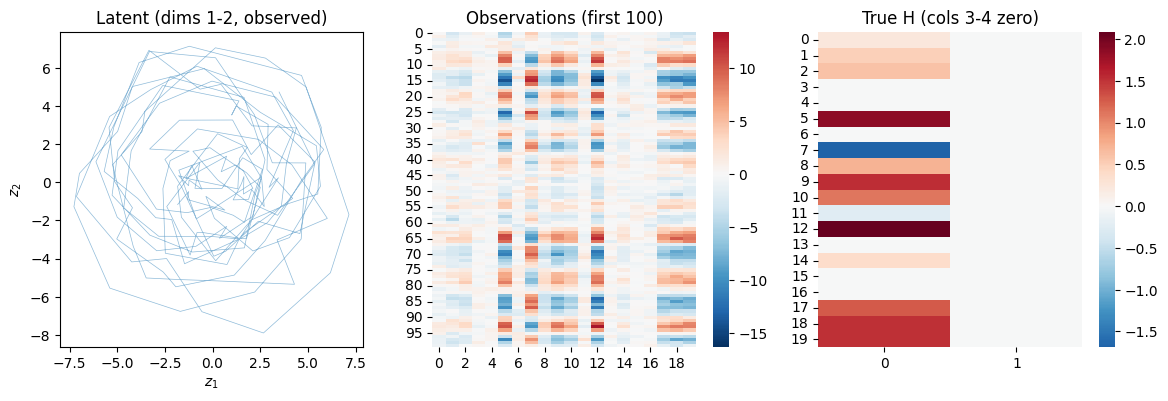

In [4]:
T = 200   # time steps
D = 20    # features
K = 2     # latent state dimension
K_obs = 1 # only first 2 components drive observations

key = jr.PRNGKey(137)

# True dynamics: damped rotation in 4D (all dimensions coupled)
rho = 0.95
theta = jnp.pi / 6
# Compose rotations in overlapping planes to couple all dims
F_true = rho * jnp.array([[jnp.cos(theta), -jnp.sin(theta)], [jnp.sin(theta),  jnp.cos(theta)]])
Q_true = jnp.eye(K)

# True loading matrix: only first K_obs columns are non-zero
key, k1, k2 = jr.split(key, 3)
H_active = jr.normal(k1, (D, K_obs)) * jr.bernoulli(k2, p=0.5, shape=(D, K_obs))
H_true = jnp.concatenate([H_active, jnp.zeros((D, K - K_obs))], axis=1)

# True diagonal noise covariance
key, k1 = jr.split(key)
R_true_diag = jr.uniform(k1, (D,), minval=0.25, maxval=1.0)
R_true = jnp.diag(R_true_diag)

# Generate latent states and observations
mu0_true = jnp.zeros(K)
Sigma0_true = jnp.eye(K)

z_true = jnp.zeros((T, K))
y_obs = jnp.zeros((T, D))

key, k1, k2 = jr.split(key, 3)
z_curr = jr.multivariate_normal(k1, mu0_true, Sigma0_true)
z_true = z_true.at[0].set(z_curr)
y_obs = y_obs.at[0].set(jr.multivariate_normal(k2, H_true @ z_curr, R_true))

for t in range(1, T):
    key, k1, k2 = jr.split(key, 3)
    z_curr = jr.multivariate_normal(k1, F_true @ z_curr, Q_true)
    z_true = z_true.at[t].set(z_curr)
    y_obs = y_obs.at[t].set(jr.multivariate_normal(k2, H_true @ z_curr, R_true))

print(f"\ny_obs shape: {y_obs.shape}, H_true shape: {H_true.shape}")
print(f"H_true: {K_obs} active columns, {K - K_obs} zero columns")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].plot(z_true[:, 0], z_true[:, 1], alpha=0.5, lw=0.5)
axes[0].set_xlabel('$z_1$'); axes[0].set_ylabel('$z_2$')
axes[0].set_title('Latent (dims 1-2, observed)')
axes[0].set_aspect('equal')
sns.heatmap(y_obs[:100], ax=axes[1], cmap='RdBu_r', center=0)
axes[1].set_title('Observations (first 100)')
sns.heatmap(H_true, ax=axes[2], cmap='RdBu_r', center=0)
axes[2].set_title('True H (cols 3-4 zero)')
plt.tight_layout()

## 2. Fit PX-VBEM with Different Dynamics Priors

We also include the default `MeanField(MVN, Delta(I))` (fixed Q=I) as a baseline.

In [5]:
NUM_ITERS = 20
has_dynamics_bias = True
n_comp = 2 * K
dyn_dim = n_comp + has_dynamics_bias  # columns in F: [F_matrix, bias]

# --- Default: MeanField(MVN, Delta(I)) — fixed Q=I ---
model_default = BDFA(n_comp, D, has_ard=True, use_bmr=True, use_px=True)
key, k1, k2 = jr.split(key, 3)
params_init_default, props_default = model_default.initialize(k1, variational_bayes=True)
params_default, elbos_default = model_default.fit_vbem(
    params_init_default, props_default, y_obs, k2,
    num_iters=NUM_ITERS, bmr_start_iter=8)
print(f"Default (Delta Q=I) final ELBO: {elbos_default[-1]:.1f}")

# --- MeanField(MVN, InverseGamma) dynamics prior ---
dyn_mf = make_mf_dynamics_prior(n_comp, dyn_dim)
model_mf = BDFA(n_comp, D, has_ard=True, use_bmr=True, use_px=True,
                dynamics_prior=dyn_mf)
key, k1, k2 = jr.split(key, 3)
params_init_mf, props_mf = model_mf.initialize(k1, variational_bayes=True)
params_mf, elbos_mf = model_mf.fit_vbem(
    params_init_mf, props_mf, y_obs, k2,
    num_iters=NUM_ITERS, bmr_start_iter=8)
print(f"MeanField(MVN, IG) final ELBO: {elbos_mf[-1]:.1f}")

# --- MVNIG dynamics prior ---
dyn_mvnig = make_mvnig_dynamics_prior(n_comp, dyn_dim)
model_mvnig = BDFA(n_comp, D, has_ard=True, use_bmr=True, use_px=True,
                   dynamics_prior=dyn_mvnig)
key, k1, k2 = jr.split(key, 3)
params_init_mvnig, props_mvnig = model_mvnig.initialize(k1, variational_bayes=True)
params_mvnig, elbos_mvnig = model_mvnig.fit_vbem(
    params_init_mvnig, props_mvnig, y_obs, k2,
    num_iters=NUM_ITERS, bmr_start_iter=8)
print(f"MVNIG (conjugate) final ELBO: {elbos_mvnig[-1]:.1f}")

Default (Delta Q=I) final ELBO: -4934.1
MeanField(MVN, IG) final ELBO: -4892.5
MVNIG (conjugate) final ELBO: -5292.0


## 3. ELBO Convergence Comparison

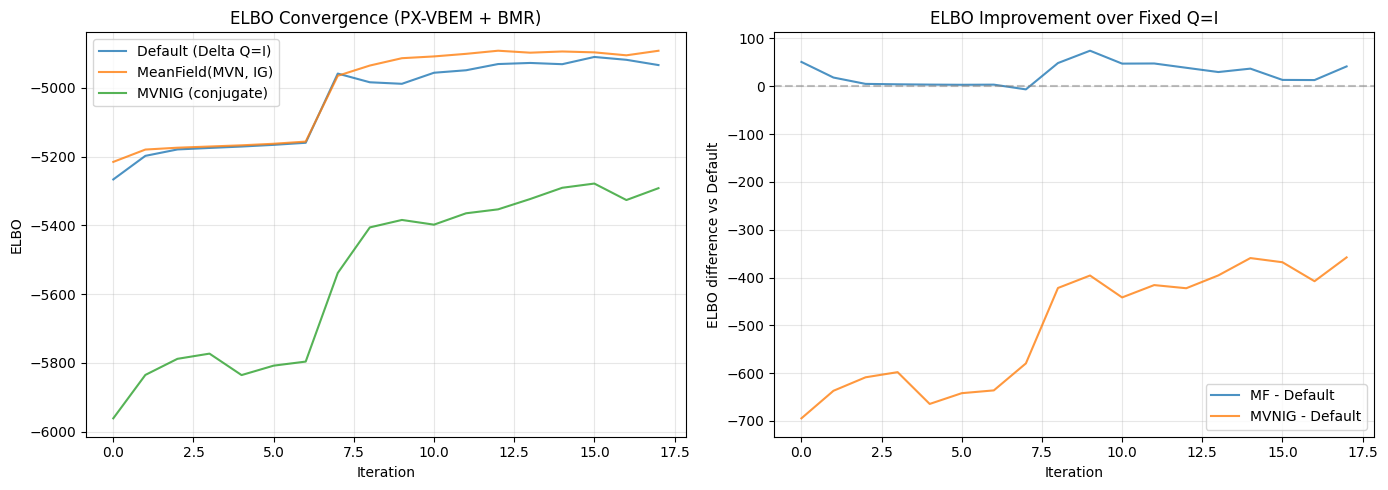

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(elbos_default[1:], label='Default (Delta Q=I)', alpha=0.8)
ax.plot(elbos_mf[1:], label='MeanField(MVN, IG)', alpha=0.8)
ax.plot(elbos_mvnig[1:], label='MVNIG (conjugate)', alpha=0.8)
ax.set_xlabel('Iteration')
ax.set_ylabel('ELBO')
ax.set_title('ELBO Convergence (PX-VBEM + BMR)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(elbos_mf[1:] - elbos_default[1:], label='MF - Default', alpha=0.8)
ax.plot(elbos_mvnig[1:] - elbos_default[1:], label='MVNIG - Default', alpha=0.8)
ax.axhline(0, ls='--', color='gray', alpha=0.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('ELBO difference vs Default')
ax.set_title('ELBO Improvement over Fixed Q=I')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

## 4. Transition Matrix Recovery

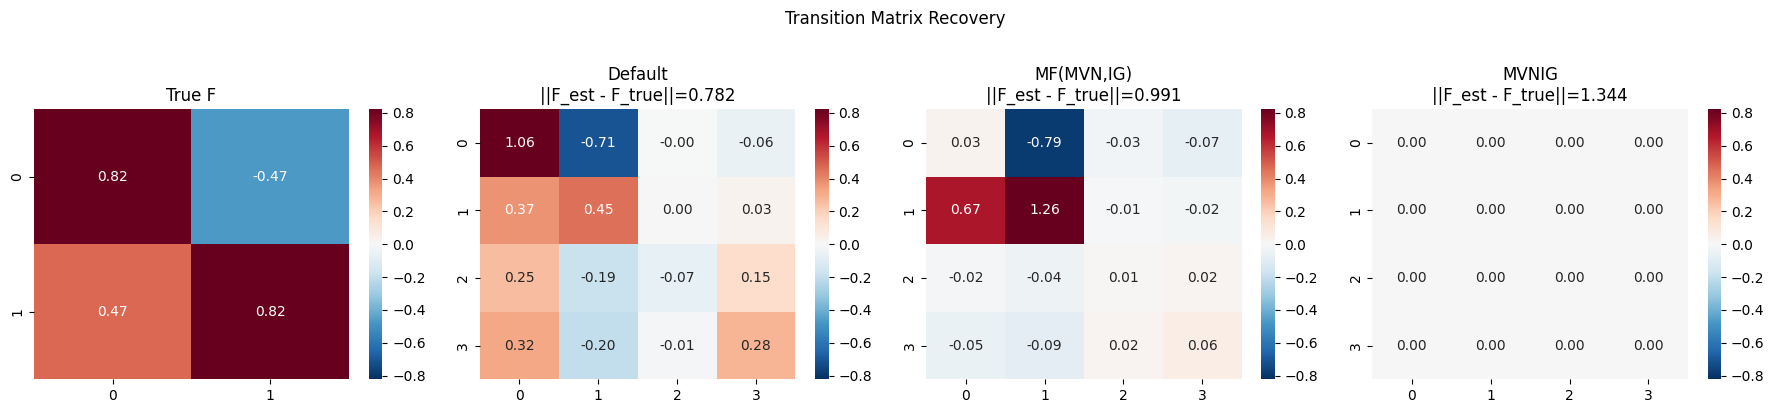

In [7]:
results = {
    'Default': params_default,
    'MF(MVN,IG)': params_mf,
    'MVNIG': params_mvnig,
}

# Procrustes alignment for each model
procrustes_Rs = {}
for name, p in results.items():
    _, _, R = procrustes_similarity(p.dynamics.weights, jnp.pad(F_true, [(0, 2), (0, 2)]))
    procrustes_Rs[name] = R

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
vmax_f = max(float(jnp.abs(F_true).max()), 0.5)

sns.heatmap(F_true, ax=axes[0], cmap='RdBu_r', center=0,
            vmin=-vmax_f, vmax=vmax_f, annot=True, fmt='.2f')
axes[0].set_title('True F')

for idx, (name, p) in enumerate(results.items()):
    R = procrustes_Rs[name]
    F_aligned = R.T @ p.dynamics.weights @ R
    err = jnp.linalg.norm(F_aligned - jnp.pad(F_true, [(0, 2), (0, 2)]), 'fro')
    sns.heatmap(F_aligned, ax=axes[idx + 1], cmap='RdBu_r', center=0,
                vmin=-vmax_f, vmax=vmax_f, annot=True, fmt='.2f')
    axes[idx + 1].set_title(f'{name}\n||F_est - F_true||={err:.3f}')

plt.suptitle('Transition Matrix Recovery', y=1.02)
plt.tight_layout()

## 5. Process Noise Q Recovery

The true process noise is $\mathbf{Q} = \mathbf{I}_4$. The default model fixes Q=I.
MeanField(MVN, IG) and MVNIG learn diagonal Q from data.

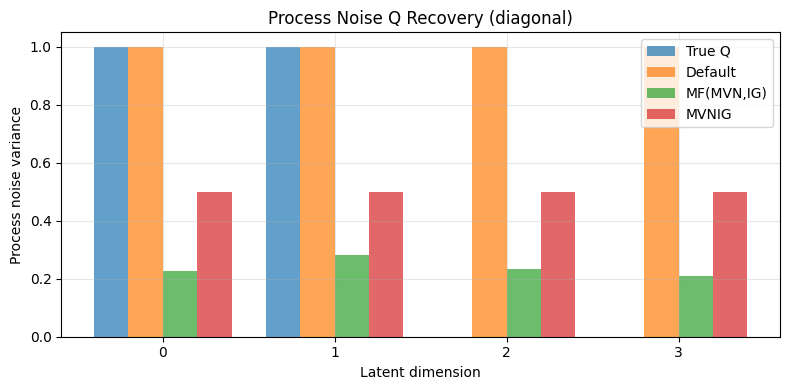

In [8]:
Q_true_diag = jnp.pad(jnp.diag(Q_true), (0, 2))

fig, ax = plt.subplots(figsize=(8, 4))
x = jnp.arange(2 * K)
width = 0.2

ax.bar(x - 1.5 * width, Q_true_diag, width=width, label='True Q', alpha=0.7)

for i, (name, p) in enumerate(results.items()):
    Q_est = p.dynamics.cov
    Q_diag = Q_est if Q_est.ndim == 1 else jnp.diag(Q_est)
    ax.bar(x + (i - 0.5) * width, Q_diag, width=width, label=name, alpha=0.7)

ax.set_xlabel('Latent dimension')
ax.set_ylabel('Process noise variance')
ax.set_title('Process Noise Q Recovery (diagonal)')
ax.set_xticks(x)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

## 6. Loading Matrix Recovery

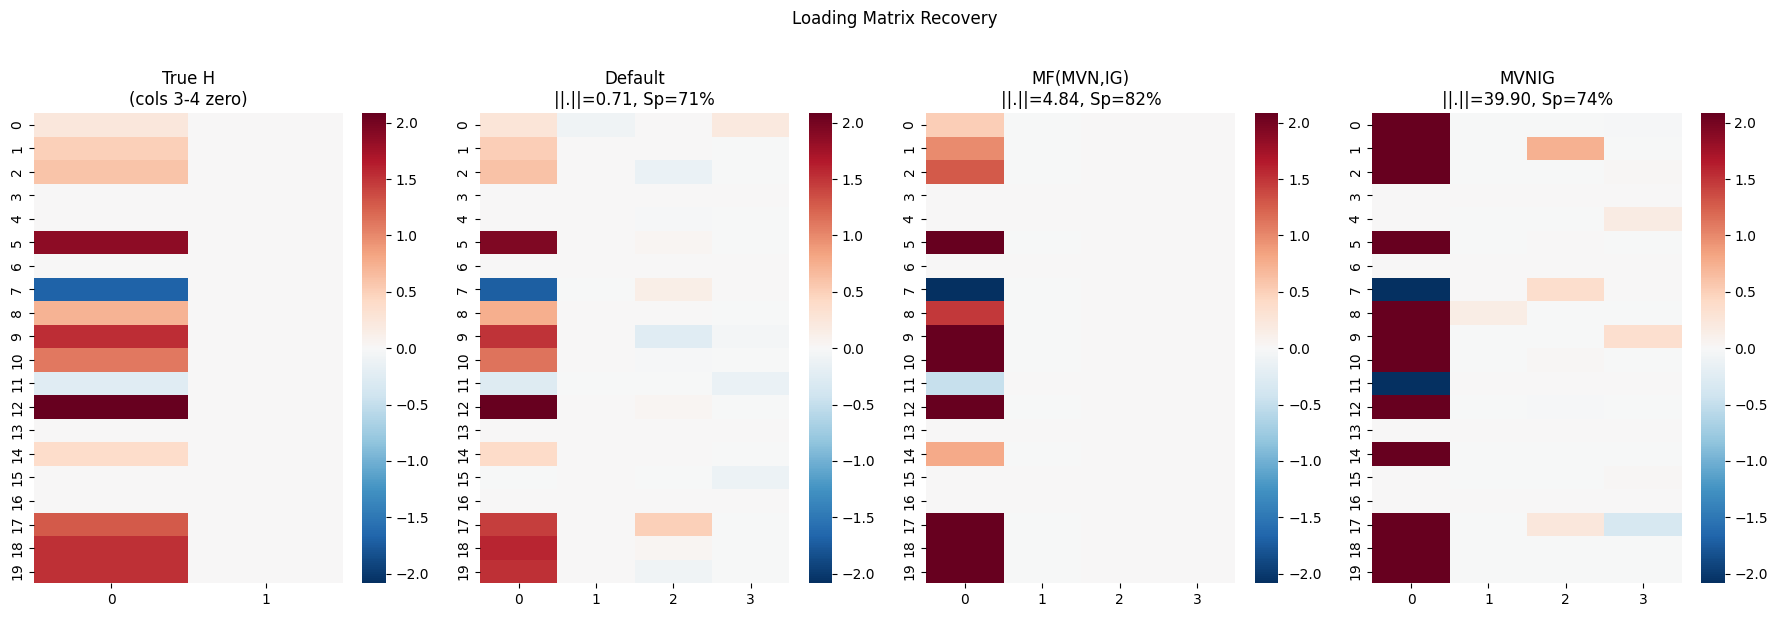

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))
vmax = jnp.abs(H_true).max()

sns.heatmap(H_true, ax=axes[0], cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax)
axes[0].set_title('True H\n(cols 3-4 zero)')

for idx, (name, p) in enumerate(results.items()):
    H_aligned, disparity, _ = procrustes_similarity(p.emissions.weights, H_true)
    sparsity = jnp.mean(jnp.abs(p.emissions.weights) < 0.05)
    sns.heatmap(H_aligned, ax=axes[idx + 1], cmap='RdBu_r', center=0,
                vmin=-vmax, vmax=vmax)
    axes[idx + 1].set_title(f'{name}\n||.||={disparity:.2f}, Sp={sparsity:.0%}')

plt.suptitle('Loading Matrix Recovery', y=1.02)
plt.tight_layout()

## 7. Latent State Recovery

Dims 1-2 (observed) should be well-recovered. Dims 3-4 (unobserved but coupled
through F) may be partially recoverable depending on how well F is estimated.

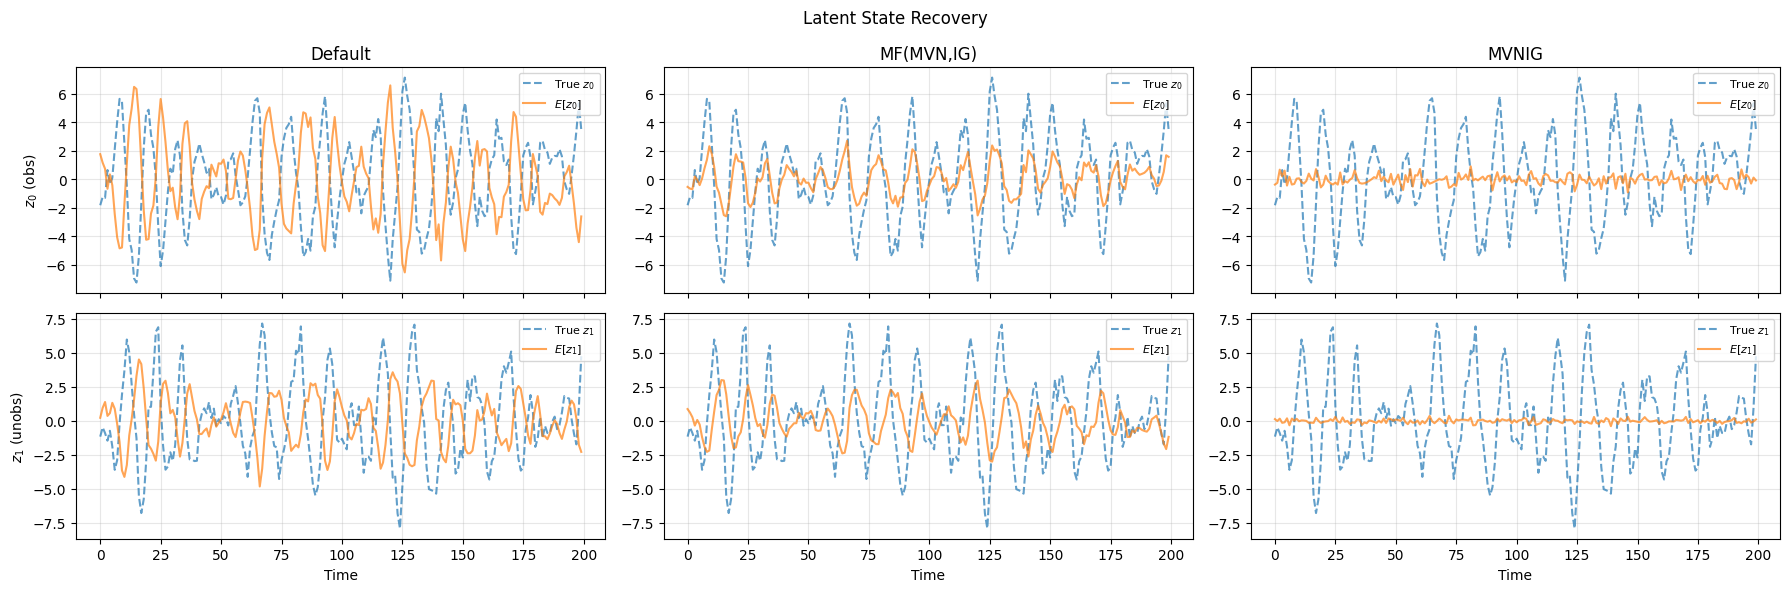

In [10]:
n_models = len(results)
fig, axes = plt.subplots(K, n_models, figsize=(6 * n_models, 3 * K), sharex=True)

for col, (name, p) in enumerate(results.items()):
    R = procrustes_Rs[name]
    post = parallel_lgssm_smoother(p, y_obs)
    Ez = jax.scipy.linalg.solve(R, post.smoothed_means[..., None])[..., 0]

    for i in range(K):
        label_suffix = ' (obs)' if i < K_obs else ' (unobs)'
        axes[i, col].plot(z_true[:, i], label=f'True $z_{i}$', ls='--', alpha=0.7)
        axes[i, col].plot(Ez[:, i], label=f'$E[z_{i}]$', alpha=0.7)
        axes[i, col].legend(loc='upper right', fontsize=8)
        axes[i, col].grid(True, alpha=0.3)
        if i == 0:
            axes[i, col].set_title(name)
        if col == 0:
            axes[i, col].set_ylabel(f'$z_{i}${label_suffix}')

for col in range(n_models):
    axes[-1, col].set_xlabel('Time')
plt.suptitle('Latent State Recovery')
plt.tight_layout()

## 8. Observation Noise Recovery

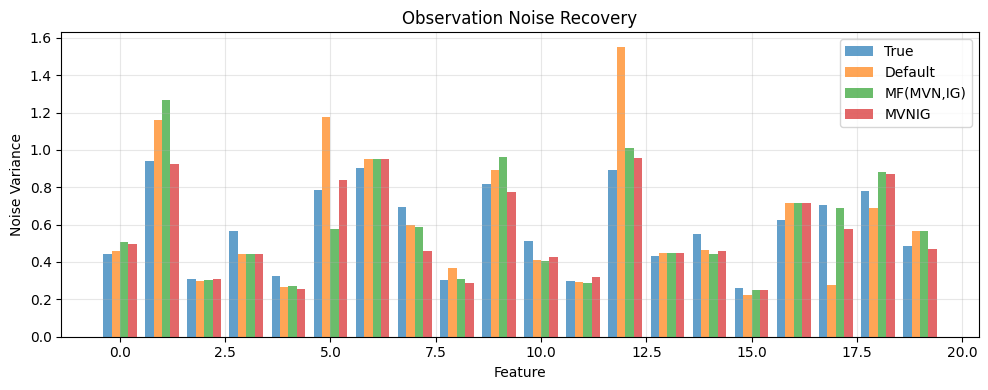

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
x = jnp.arange(D)
width = 0.2

ax.bar(x - 1.5 * width, R_true_diag, width=width, label='True', alpha=0.7)

for i, (name, p) in enumerate(results.items()):
    R_est = p.emissions.cov
    R_diag = R_est if R_est.ndim == 1 else jnp.diag(R_est)
    ax.bar(x + (i - 0.5) * width, R_diag, width=width, label=name, alpha=0.7)

ax.set_xlabel('Feature')
ax.set_ylabel('Noise Variance')
ax.set_title('Observation Noise Recovery')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()